# Piper Cherokee
Tutorial for CFD beginners or new-to-Luminary users walking through setting up an external aerodynamics simulation.

Based on the UI tutorial: https://docs.luminarycloud.com/en/articles/10157837-piper-cherokee

## In this Tutorial

The Piper PA-28 Cherokee is a small single-propeller aircraft intended for flight training and personal use. This tutorial will guide you through demonstrating and using Luminary Cloud's external aerodynamics solution.

Follow the steps to upload a CAD file, generate a computational mesh, and analyze aerodynamic features.

<img src="https://storage.googleapis.com/luminarycloud-learning/sample-projects/piper-cherokee/notebook-images/01-piper-cherokee-flow-vectors.png" width=600 />


## Initialize the SDK
A simple way to use the SDK is to create a .env file with your API key. Create a file named .env with one line:

```LC_API_KEY=YOUR_API_KEY```

You can generate an API key in the UI by navigating to My Account -> Profile in the left navigation menu under the heading "API Keys".

### Set your API key in the environment
The simplest way to use the SDK is to create an API key in the UI and assign it to the environment variable LC_API_KEY before running this notebook.

Alternatively, you can use the python-dotenv python package (see https://pypi.org/project/python-dotenv/) and create a .env file with your API key specified as:

`LC_API_KEY=MY_API_KEY`

Note that if you do not set the API key, you will be asked to authenticate interactively when you make your first SDK request.

In [75]:
# Uncomment to use python-dotenv for loading LC_API_KEY into the environment from a .env file
# from dotenv import load_dotenv
# load_success=load_dotenv()

## Install the Luminary SDK and plotting libraries

##### Before using the Luminary SDK, you need to install it in your python environment using the following command:

```pip install luminarycloud```

##### You will also need these libraries for post-processing:

```pip install plotly.express```

```pip install nbformat```

## Import dependencies
Next, we need to import the libraries that we will be using in this tutorial:

In [2]:
import luminarycloud as lc
import luminarycloud.vis as vis
from typing import Union, List, cast
from pathlib import Path
from luminarycloud.geometry import Surface, Volume

from datetime import datetime
import time
from uuid import uuid4
import threading

import pandas as pd
import plotly.express as px
from PIL import Image

from IPython.display import display, update_display


## Create a New Project
To create a new project, use the lc.create_project(name=name, description=description) command.

In [ ]:
project = lc.create_project(
    name="Piper Cherokee SDK Tutorial",
    description="This is a demo of the Luminary Cloud SDK with the Piper Cherokee",
)
print(project)

id: "p-s3dggn283nyag0hdom4pkp1a4buiektktysdbs9lnoyhcz6cyc"
name: "Piper Cherokee SDK Tutorial - Test2"
description: "This is a demo of the Luminary Cloud SDK with the Piper Cherokee"
create_time {
  seconds: 1744388961
  nanos: 675675000
}
update_time {
  seconds: 1744388961
  nanos: 689062000
}



You can now view the created project in the UI and everything executed in this tutorial will be synchronized.

## Upload the geometry (CAD)

Now upload the Piper Cherokee model to your project. To do this, use:

`geometry = project.create_geometry(cad_file_path, name="CAD name", wait=True)`

The `wait=True` parameter will wait until the geometry load is done before returning.

You can download the piper cherokee CAD file [here](https://storage.googleapis.com/luminarycloud-learning/sample-projects/piper-cherokee/cad/piper-cherokee-cad.step).


In [ ]:
cad_file = "./piper-cherokee-tutorial-cad.x_t" # set path to the cad file
geometry = project.create_geometry(Path(cad_file), name="Piper Cherokee Model", wait=True) # create geomtery
print(geometry)

id: "geo-69f50bc8-3062-43db-ae7c-1f971e77e849"
name: "Piper Cherokee Model"
create_time {
  seconds: 1744388971
  nanos: 209600000
}
last_version_id: "geover-622db25c-6f17-415a-9d9a-42282d6a3183"
uses_tags: true
project_id: "p-s3dggn283nyag0hdom4pkp1a4buiektktysdbs9lnoyhcz6cyc"



## Identify farfield and plane surfaces
Let's examine the geometry by getting its surfaces and volumes.

In [ ]:
surfaces, volumes = geometry.list_entities() # extract surface and volume data
print(surfaces)

[Surface(geometry_id='geo-69f50bc8-3062-43db-ae7c-1f971e77e849', id='0/bound/BC_1', bbox_min=Vector3(x=0.0, y=-0.17983303307707665, z=-0.17983303307707665), bbox_max=Vector3(x=0.421269146666592, y=0.17983303307707665, z=0.17983303307707665), _native_id=1), Surface(geometry_id='geo-69f50bc8-3062-43db-ae7c-1f971e77e849', id='0/bound/BC_2', bbox_min=Vector3(x=2.329999167791865, y=-4.370000151875303, z=0.060825817774542504), bbox_max=Vector3(x=2.4259492166773455, y=-4.271685350811265, z=0.24046253956063351), _native_id=2), Surface(geometry_id='geo-69f50bc8-3062-43db-ae7c-1f971e77e849', id='0/bound/BC_3', bbox_min=Vector3(x=2.3278883186636374, y=4.269573156785031, z=0.05871991406272295), bbox_max=Vector3(x=2.428060097375441, y=4.370004313597518, z=0.24052975302330515), _native_id=3), Surface(geometry_id='geo-69f50bc8-3062-43db-ae7c-1f971e77e849', id='0/bound/BC_11', bbox_min=Vector3(x=2.4207053744952423, y=-4.370014662586041, z=0.06102492649774846), bbox_max=Vector3(x=3.915572379826732, y=-

### Farfield surfaces

In [ ]:
farfield_surface_id = "0/bound/BC_14" # in this model the farfield has an id of '0/bound/BC_14' so we will use this to distinguish the objects.
farfield_surfaces = [surface for surface in surfaces if surface.id == farfield_surface_id] # extract farfield surface from surfaces
farfield_surface_ids = [s.id for s in farfield_surfaces] # extract ids for later use
print(farfield_surface_ids) # print to verify

['0/bound/BC_14']


### Plane surfaces

In [ ]:
plane_surfaces = [surface for surface in surfaces if surface.id not in farfield_surface_ids] # extract plane surfaces (non farfield surfaces)
plane_surface_ids = [s.id for s in plane_surfaces] # extract ids for later use
print(plane_surface_ids)

['0/bound/BC_1', '0/bound/BC_2', '0/bound/BC_3', '0/bound/BC_11', '0/bound/BC_12', '0/bound/BC_13', '0/bound/BC_15', '0/bound/BC_16', '0/bound/BC_17', '0/bound/BC_18', '0/bound/BC_19', '0/bound/BC_20', '0/bound/BC_21', '0/bound/BC_22', '0/bound/BC_23', '0/bound/BC_24', '0/bound/BC_25', '0/bound/BC_26', '0/bound/BC_27', '0/bound/BC_28', '0/bound/BC_29', '0/bound/BC_30', '0/bound/BC_31', '0/bound/BC_32', '0/bound/BC_33', '0/bound/BC_34', '0/bound/BC_35', '0/bound/BC_36', '0/bound/BC_37', '0/bound/BC_38', '0/bound/BC_39', '0/bound/BC_40', '0/bound/BC_41', '0/bound/BC_42', '0/bound/BC_43', '0/bound/BC_44', '0/bound/BC_45', '0/bound/BC_46', '0/bound/BC_47', '0/bound/BC_48', '0/bound/BC_49', '0/bound/BC_50', '0/bound/BC_51', '0/bound/BC_52', '0/bound/BC_53', '0/bound/BC_54', '0/bound/BC_55', '0/bound/BC_56', '0/bound/BC_57', '0/bound/BC_58', '0/bound/BC_59', '0/bound/BC_60', '0/bound/BC_61', '0/bound/BC_62', '0/bound/BC_63', '0/bound/BC_64', '0/bound/BC_65', '0/bound/BC_66', '0/bound/BC_67',

## Create tags
Read more about tags in the documentation [here](https://docs.luminarycloud.com/en/articles/10084037-geometry-management-with-tags).

In [ ]:
## Create the farfield and plane tags
# create tags for the far field and plane based on the identified surfaces.
geometry.create_tag("Far-field", cast(List[Union[Volume, Surface]], farfield_surfaces))
geometry.create_tag("Plane", cast(List[Union[Volume, Surface]], plane_surfaces))


## Create the fluid volume tag
# create a new tag "Fluid Volume" from the one volume in the geometry. It must be passed as a list.
fluid_volume = volumes[0]
geometry.create_tag("Fluid Volume", [fluid_volume])

Now we can look at the tag information:

In [ ]:
tag_info = {
    tag.name: {
        "name": tag.name,
        "id": tag.id,
        "num_surfaces": len(tag.surfaces),
        "num_volumes": len(tag.volumes),
    }
    for tag in geometry.list_tags()
}
tag_info

## Validate geometry

The geometry will now be checked to ensure it is of sufficient quality.

This will validate the geometry, and may take a few seconds to a few minutes. If no issues are found, the first parameter will return true, otherwise the first parameter will be false and the second parameter will be a list of the issues.

In [74]:
geometry_ok, issues = geometry.check()
issues if not geometry_ok else "OK"

'OK'

## Load the geometry to setup

This step is needed only if we want to see the model in the UI Setup screen.
_NOTE: this operation is irreversible and deletes all the existing meshes and simulations in the project._

In [75]:
project.load_geometry_to_setup(geometry)

## Generate Mesh

Before running a simulation, we'll need to generate a computational mesh based on the geometry in the project.

First we'll set up the parameters that are used to generate the mesh. Normally, you'll want to iterate this process, starting with a coarser mesh and refining it as needed.

In this tutorial, we'll go ahead and generate the final mesh.

### Define model, volume, and boundary layer parameters

Here we set the meshing parameters for the surface mesh model, volume, and boundary layer. 

In [ ]:
# surface model meshing parameters
model_meshing_params = lc.meshing.ModelMeshingParams(
    surfaces=cast(List[Union[Surface, str]], plane_surfaces),
    curvature=4,
    max_size=0.05,
)

# set volume mesh parameters
volume_meshing_params = lc.meshing.VolumeMeshingParams(
    volumes=volumes,
    min_size=0.005,
    max_size=50,
)

#set boundary layer parameters
boundary_layer_params = lc.meshing.BoundaryLayerParams(
    surfaces=cast(List[Union[Surface, str]], plane_surfaces),
    n_layers=20,
    initial_size=0.00001,
    growth_rate=1.2,
)

### Define sizing strategy
Set the sizing strategy for the mesh. You can choose from the following:

| Strategy    | Description               | Notes          |
| :- | :- | :- |
| lc.meshing.sizing_strategy.Minimal() | Minimal sizing strategy parameters. | If this is used, all other meshing parameters are ignored. |
| lc.meshing.sizing_strategy.TargetCount(value) | Sizing strategy based on a target number of cells. | To reach a target number of cells, the edge length specifications will be proportionally scaled throughout the mesh. Requested boundary layer profiles will be maintained. |
| lc.meshing.sizing_strategy.MaxCount(value)   | Sizing strategy based on a maximum number of cells. | If the mesh becomes larger than the max cell count, the mesh will be scaled. Requested boundary layer profiles will be maintained. |

We will use a target number of 20 million cells.

In [79]:
target_count = 20_000_000
sizing_strategy = lc.meshing.sizing_strategy.TargetCount(target_count)

### Set mesh parameters

Now we set the meshing parameters based on the values we just set.

Note that we need to specify the geometry ID shown earler, the sizing strategy, the model, volume, and boundary layer parameters, and the minimum and maximum size.

In [ ]:
mesh_params = lc.meshing.MeshGenerationParams(
    geometry_id=geometry.id,
    sizing_strategy=sizing_strategy,
    volume_meshing_params=[volume_meshing_params],
    model_meshing_params=[model_meshing_params],
    boundary_layer_params=[boundary_layer_params],
    min_size=0.005,
    max_size=50,
)

### Create mesh

Now we create the mesh. This will take about 10 minutes. We've added some code to provide status updates as the mesh is being generated.

In [ ]:
mesh = None

def run_mesh_creation() -> None:
    global mesh
    mesh = project.create_or_get_mesh(mesh_params, name="Piper Cherokee 20M mesh")


thread = threading.Thread(target=run_mesh_creation)
thread.start()

elapsed_seconds = 0
wait_seconds = 30

current_time = datetime.now().isoformat()
display(
    f"{current_time}: elapsed: {elapsed_seconds//60:02d}:{elapsed_seconds%60:02d}",
    display_id="status_display",
)

while True:
    meshes = project.list_meshes()
    if len(meshes) > 0 and all(m.status.name == "COMPLETED" for m in meshes):
        update_display(
            f"{current_time}: elapsed: {elapsed_seconds//60:02d}:{elapsed_seconds%60:02d}; mesh has been generated.",
            display_id="status_display",
        )
        break
    else:
        current_time = datetime.now().isoformat()
        update_display(
            f"{current_time}: elapsed: {elapsed_seconds//60:02d}:{elapsed_seconds%60:02d}; waiting...",
            display_id="status_display",
        )
        time.sleep(wait_seconds)
        elapsed_seconds += wait_seconds


'2025-04-11T09:54:33.720329: elapsed: 00:00; waiting...'

KeyboardInterrupt: 

## Set up physics

In [133]:
from luminarycloud import EntityIdentifier

fluid_flow_physics = lc.params.simulation.Physics() # create physics node

fluid_flow_physics.physics_identifier = EntityIdentifier(id=str(uuid4()), name="fluid_flow_physics") # set identifier
fluid_flow_physics.fluid = lc.params.simulation.physics.Fluid() # set physics to fluid

fluid_flow_physics.fluid.initialization = (
    lc.params.simulation.physics.fluid.initialization.FluidFarfieldValues() # initialize from far-field values
)

### Create boundary conditions

First create a global frame which will be referenced by the body frame.

In [134]:
global_frame_id = "global_frame_id"

global_frame = lc.params.simulation.MotionData(frame_id=global_frame_id, frame_name="Global")

### Define the body frame and motion data

This information is required if you want to define flow conditions using angles of attack, as we did for the far-field above, or if you need to calculate output quantities such as lift or drag (i.e., for all of these you need to know which directions constitute forwards, upwards, etc.).

Origin is set to 0, 0, 0, pointing from the center of the airplane out through its starboard wing.

Orientation is set to 0, 180, 0, pointing from the center of the airplane out through its nose.

In [135]:
origin = lc.types.Vector3(0, 0, 0)
orientation = lc.types.Vector3(0, 180, 0)

body_frame = lc.params.simulation.MotionData(
    frame_id="body_frame_id",
    frame_name="body_frame",
    frame_parent=global_frame_id,
    frame_transforms=[
        lc.params.simulation.motion_data.frame_transforms.TranslationalTransform(
            transform_name="body_frame_origin", translation=origin
        ),
        lc.params.simulation.motion_data.frame_transforms.RotationalTransform(
            transform_name="body_frame_orientation", rotation_angles=orientation
        ),
    ],
)

In [136]:
# Create a new Physics object with the body_frame and motion_data attributes
sim_params = lc.SimulationParam() # create simulation parameters object
sim_params.body_frame = lc.params.simulation.BodyFrame(body_frame_id=body_frame.frame_id) # apply the body frame
sim_params.motion_data = [global_frame, body_frame] # set global and body frame for motion

We'll use these later when we assign the physics to the simulation parameters

### Set up material (air)

In [137]:
# ideal gas
material_model = lc.params.simulation.material.fluid.material_model.IdealGas(
    molecular_weight=28.966,
    specific_heat_cp=1006.4,
)

# set thermal conductivity
thermal_conductivity_model = (
    lc.params.simulation.material.fluid.thermal_conductivity_model.PrescribedPrandtlNumber(
        prandtl_number=0.72,
    )
)

# set viscosity
viscosity_model = lc.params.simulation.material.fluid.viscosity_model.Sutherland(
    reference_viscosity=1.716e-5,
    reference_temperature=264.37,
    sutherland_constant=110.56,
)

# set fluid material as standard air
fluid_material = lc.params.simulation.material.MaterialFluid(
    reference_pressure=0,
    material_model=material_model,
    thermal_conductivity_model=thermal_conductivity_model,
    viscosity_model=viscosity_model,
)

# apply fluid material to simulation
air_material = lc.params.simulation.MaterialEntity(
    material_identifier=EntityIdentifier(id=str(uuid4()), name="air_fluid"),
    fluid=fluid_material,
)

### Boundary conditions

#### Define wall boundary condition

The wall boundary condition represents a solid, impermeable surface where the flow interacts with a physical object, such as an aircraft fuselage, a car body, or a pipe wall. The specific treatment of the boundary depends on whether the flow is no-slip (viscous flow) or slip (inviscid flow).

For this simulation we set the wall boundary to the surfaces of the plane, and the momentum as no-slip.

In [138]:
# Create the wall boundary condition
wall_bc = lc.params.simulation.physics.fluid.boundary_conditions.Wall(
    name="Wall", # wall BC
    surfaces=[s.id for s in plane_surfaces], # apply to plane surfaces
    momentum=lc.params.simulation.physics.fluid.boundary_conditions.wall.momentum.NoSlip(), # apply no-slip condition
)

#### Define far field boundary condition

Your farfield boundary defines the atmospheric conditions in which your aircraft is flying. The farfield ensures that disturbances from the aircraft dissipate naturally, preventing artificial reflections. These values define the ambient conditions that your aircraft or object is moving through.

In [139]:
farfield_bc = lc.params.simulation.physics.fluid.boundary_conditions.Farfield(
    name="Farfield", # The name of the farfield boundary condition
    surfaces=farfield_surface_ids, # This is a list of the IDs for the surfaces that define the far field boundary.
    mach_number=0.216, # This defines a subsonic flow condition (about 73.4 m/s if the speed of sound is ~340 m/s).
    pressure=70100, # This is the static pressure at the farfield, which is lower than sea-level atmospheric pressure (suggesting a higher-altitude simulation).
    temperature=288.15, # This is 15°C, close to standard sea-level conditions in the International Standard Atmosphere (ISA).
    direction_specification=lc.params.enum.FarFieldFlowDirectionSpecification.FARFIELD_ANGLES, # This means the flow direction is set using angles (instead of velocity components).
    angle_alpha=2.0, # The flow is coming in at a slight upward angle (2° AoA), which is common for lift-producing wings.
    angle_beta=0.0, # No sideslip angle, meaning the flow is aligned with the aircraft’s centerline in the lateral direction.
)

#### Set boundary conditions

The boundary conditions includes the farfield and wall boundary conditions.

In [140]:
fluid_flow_physics.fluid.boundary_conditions = [farfield_bc, wall_bc] # apply the previously defined BCs

## Create and apply simulation parameters

In [141]:
sim_params = lc.SimulationParam() # create the simulation params object
sim_params.body_frame = lc.params.simulation.BodyFrame(body_frame_id=body_frame.frame_id) # assign the body frame
sim_params.assign_material(air_material, fluid_volume)  # assign the material
sim_params.assign_physics(fluid_flow_physics, fluid_volume)  # assign physics

## Simulation

### Create a simulation template

We use a simulation template to hold the parameters for a simulation. In order to run the simulation, first create a simulation template based on the simulation parameters.

In [142]:
simulation_template = project.create_simulation_template(
    name="piper simulation parameters", parameters=sim_params._to_proto()
)

### Configure outputs

We output equation residuals and surface-integrated scalar outputs at every iteration, on all surfaces, volumes, monitor planes, and monitor points. This allows you to extract outputs after running a simulation without requiring you to re-run the simulation!

However, if you’d like to define a stopping condition based on an output, you need to define a specific output first. Otherwise, declaring outputs up front is optional.

In [143]:
lift = simulation_template.create_output_definition(
    lc.outputs.ForceOutputDefinition(
        name="Lift",
        quantity=lc.enum.QuantityType.LIFT,
        surfaces=[s.id for s in plane_surfaces],
        reference_frame_id=body_frame.frame_id,
    )
)

In [144]:
drag = simulation_template.create_output_definition(
    lc.outputs.ForceOutputDefinition(
        name="Drag",
        quantity=lc.enum.QuantityType.DRAG,
        surfaces=[s.id for s in plane_surfaces],
        reference_frame_id=body_frame.frame_id,
    )
)

### Set stopping conditions

Stopping Conditions are used to determine when a simulation exits and saves results. Here we set a stopping condition based on one of the custom outputs we just defined, and we'll stop the simulation after a maximum number of iterations even if the stopping condition is unmet.

In [145]:
simulation_template.create_or_update_stopping_condition(
    output_definition_id=lift.id,
    threshold=0.0001,  # 0.01%
    start_at_iteration=500,
    averaging_iterations=10,
    iterations_to_consider=5,
)

StoppingCondition(id='stopcond-35aa1db6-765d-4aa4-b75f-cef85a7f2668', output_definition_id='outnode-9b738215-814a-458e-ae0c-4f84f5f83f3a', threshold=0.0001, start_at_iteration=500, averaging_iterations=10, iterations_to_consider=5)

In [146]:
simulation_template.update_general_stopping_conditions(max_iterations=2000) # add max iteration BC if output stopping conditions are not met

/var/folders/3x/v63w04d52hl6svd1v5lbn3nw0000gn/T/ipykernel_23913/225771203.py:1: FutureWarning:

update_general_stopping_conditions() is an experimental feature and may change or be removed without notice.

/Users/josephwarner/Documents/API/lib/python3.11/site-packages/luminarycloud/simulation_template.py:441: FutureWarning:

update_general_stopping_conditions() is an experimental feature and may change or be removed without notice.



GeneralStoppingConditions(max_iterations=2000, max_physical_time=0.0, max_inner_iterations=0, stop_on_any=False)

### Run the simulation

In [ ]:
simulation_name = "Piper simulation"
batch_processing = True # Note: setting batch_processing to False will run the simulation as a Priority job

simulation = project.create_simulation(
    mesh.id,
    simulation_name,
    simulation_template.id,
    batch_processing=batch_processing,
)
print(simulation)

Note that the status is **SIMULATION_STATUS_ACTIVE** (**ACTIVE**) while running. We must wait for the simulation to finish.

In [113]:
# Wait for simulation
done = False
spinner = "⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏"
display(f"Status: {simulation.status.name}⠏", display_id="status_display")
i = 0
while not done:
    sim_status = project.list_simulations()[0].status.name
    if sim_status != "ACTIVE":
        update_display(f"Status: {sim_status}", display_id="status_display")
        done = True
        break
    i += 1
    update_display(f"Status: {sim_status}{spinner[i % len(spinner)]}", display_id="status_display")
    time.sleep(0.5)

'Status: COMPLETED'

## Plot residuals

Now we can download the residuals as CSV and plot them.

In [ ]:
with simulation.download_global_residuals() as stream:
    # since this is a steady state simulation, we can drop these columns
    residuals_df = pd.read_csv(stream, index_col="Iteration index").drop(
        ["Time step", "Physical time"], axis=1
    )
residuals_df

,Continuity Residual,X-Momentum Residual,Y-Momentum Residual,Z-Momentum Residual,Energy Residual,Spalart-Allmaras Variable Residual
Iteration index,,,,,,
1,0.903611,0.857275,0.860312,0.864638,0.904695,0.761173
2,0.842118,0.744565,0.786411,0.794081,0.844210,0.578139
3,0.794321,0.658446,0.747125,0.757541,0.797106,0.442031
4,0.752009,0.589366,0.720401,0.732978,0.755239,0.339586
5,0.713879,0.533062,0.698251,0.712290,0.717335,0.261538
...,...,...,...,...,...,...
958,0.004419,0.008659,0.021241,0.014665,0.004442,1.343970
959,0.004362,0.008491,0.020351,0.014104,0.004389,1.346385
960,0.004297,0.008281,0.019213,0.013417,0.004328,1.348837


In [7]:
# We want to plot all residuals on a log scale (residuals are typically shown this way)
# 'Spalart-Allmaras Variable' is also available for plotting
fig = px.line(
    residuals_df,
    x=residuals_df.index,
    y=["X-Momentum Residual", "Y-Momentum Residual", "Z-Momentum Residual", "Energy Residual"],
    title="Residuals vs Iteration",
    template="plotly_white",
    log_y=True,
)  # Using log scale for y-axis since these are residuals

fig.update_layout(
    xaxis_title="Iteration",
    yaxis_title="Residual Value",
    width=1000,
    height=600,
    showlegend=True,
    legend_title="Residual Type",
    legend=dict(
        orientation="h",  # horizontal orientation
        yanchor="bottom",
        y=-0.2,  # position below the plot
        xanchor="center",
        x=0.5,  # centered horizontally
    ),
)

# Optional: Update line styles for better visibility
fig.update_traces(mode="lines")

fig.show()

In [8]:
# import relevant lcomponents
from luminarycloud.enum import ReferenceValuesType
from luminarycloud.reference_values import ReferenceValues
from luminarycloud.enum import QuantityType, ReferenceValuesType

# set reference values
ref_vals = ReferenceValues(
    reference_value_type=ReferenceValuesType.PRESCRIBE_VALUES,
    area_ref=10.0,
    length_ref=10.0,
    p_ref=101325.0,
    t_ref=273.15,
    v_ref=265.05709547039106,
)


target_boundaries = ["0/bound/BC_1"] # get target surfaces (plane surface)

# see documentation for more details about available parameters
with simulation.download_surface_output(
    QuantityType.LIFT, target_boundaries, frame_id=body_frame.frame_id, reference_values=ref_vals
) as stream:
    # since this is a steady state simulation, we can drop "Time step" and "Physical time"
    lift_df = pd.read_csv(stream, index_col="Iteration index").drop(
        ["Time step", "Physical time"], axis=1
    )
    # rename lift column for clarity
    lift_df = lift_df.rename(columns={"Lift - 0/bound/BC_1": "lift"})  # create a dataframe
    print(lift_df)

NameError: name 'body_frame' is not defined

In [9]:
fig = px.line(lift_df, y="lift", title="Lift vs Iteration", template="plotly_white")

fig.update_layout(xaxis_title="Iteration", yaxis_title="Lift", width=800, height=500)

fig.show()

NameError: name 'lift_df' is not defined

In [ ]:
# get drag output
with simulation.download_surface_output(
    QuantityType.DRAG, target_boundaries, frame_id=body_frame.frame_id, reference_values=ref_vals
) as stream:
    # since this is a steady state simulation, we can drop "Time step" and "Physical time"
    drag_df = pd.read_csv(stream, index_col="Iteration index").drop(
        ["Time step", "Physical time"], axis=1
    )
    # rename drag column
    drag_df = drag_df.rename(columns={"Drag - 0/bound/BC_1": "drag"}) # create a dataframe
    print(drag_df)

                        drag
Iteration index             
1               -2965.168062
2               -2918.946104
3               -2876.654315
4               -2838.824035
5               -2806.352952
...                      ...
958             -2981.569721
959             -2981.273752
960             -2980.947708
961             -2980.604358
962             -2980.256948

[962 rows x 1 columns]


In [126]:
fig = px.line(drag_df, y="drag", title="Drag vs Iteration", template="plotly_white")

fig.update_layout(xaxis_title="Iteration", yaxis_title="Drag", width=800, height=500)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### Visualizing flow movement

One of the powerful abilities of computational fluid dynamics is that it can allow us to visualize the usually invisible movement of a fluid past an object. This understanding can be critical in improving the designs of vehicles and aircraft.

Note: this may take a few minutes

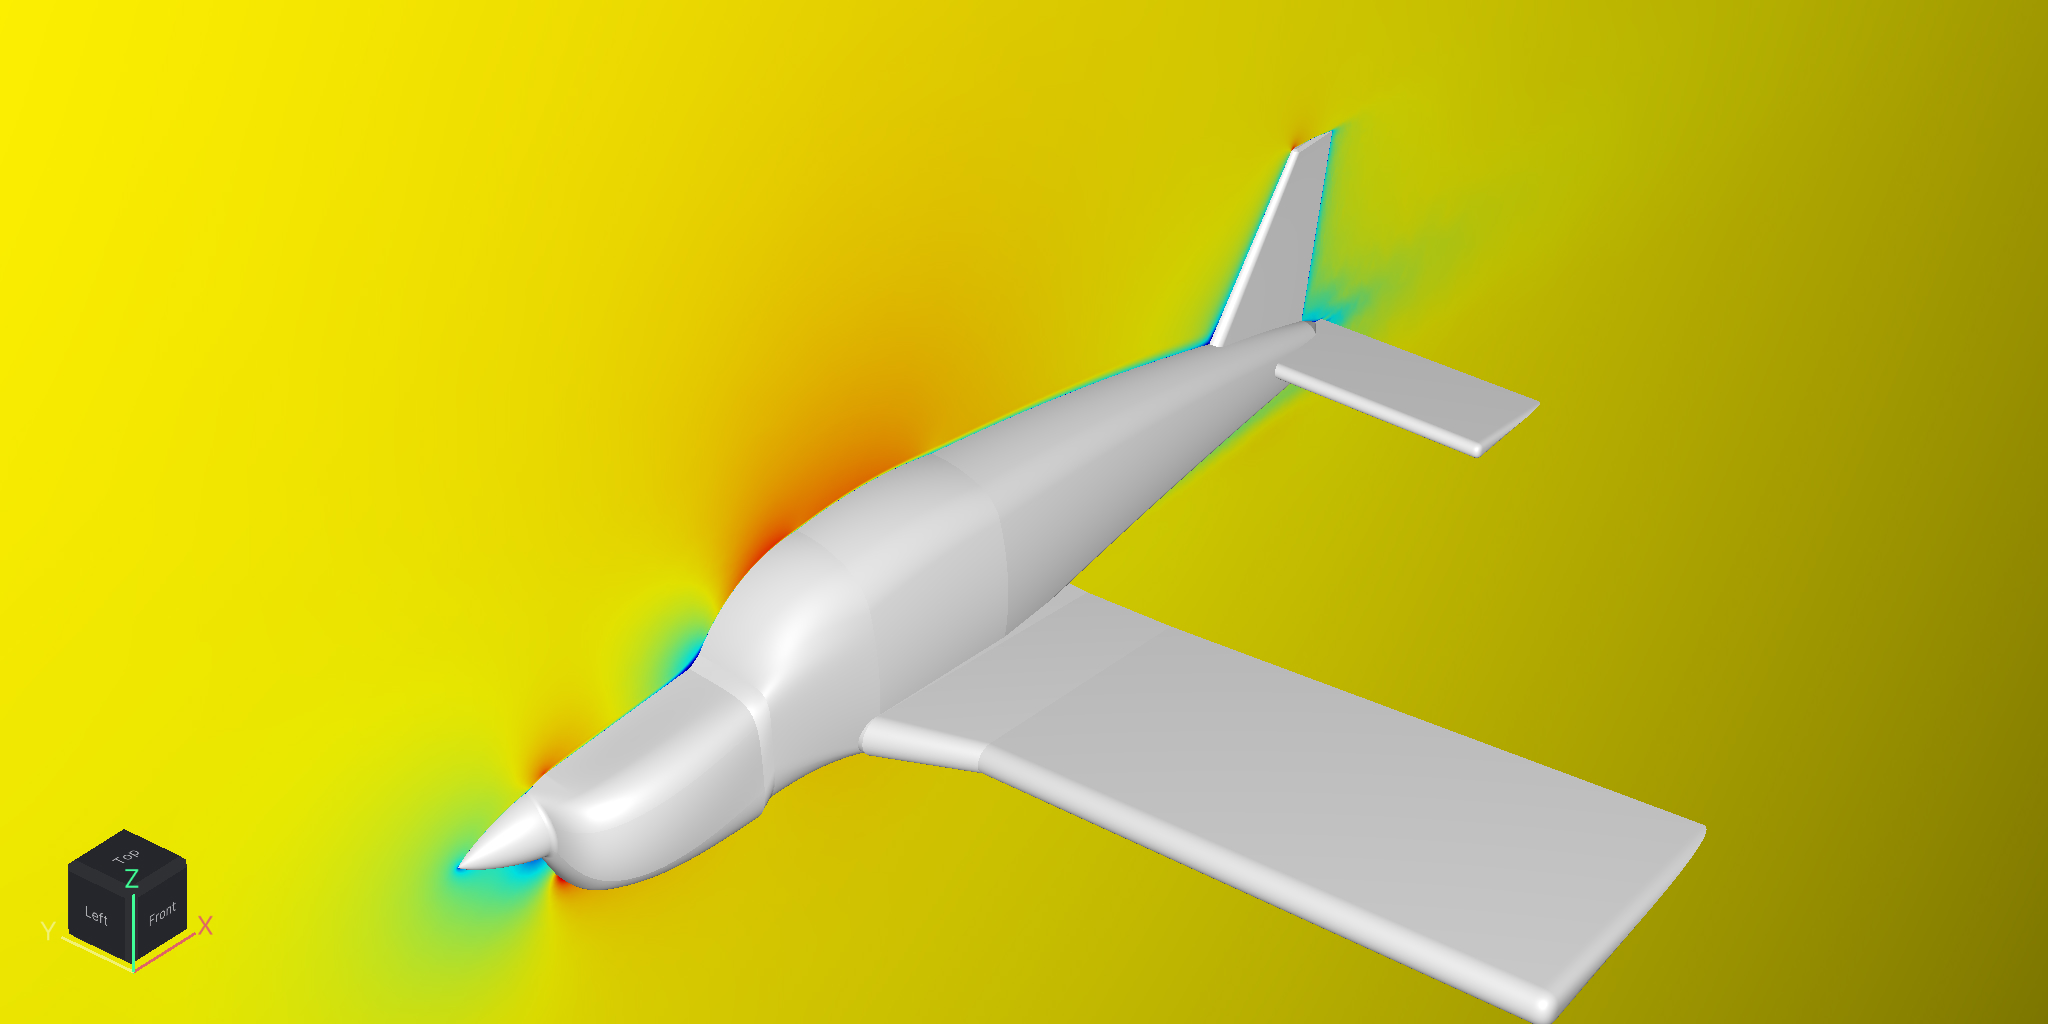

In [127]:

# Pick the last iteration
solution = simulation.list_solutions()[-1]
scene = vis.Scene(solution)

# Hide the far field surface
scene.hide_far_field()
scene.global_display_attrs.representation = vis.Representation.SURFACE
scene.global_display_attrs.field.quantity = vis.VisQuantity.NONE

camera = vis.LookAtCamera()
camera.look_at = [4.0, 0.0, 0.0]
camera.position = [-4.0, -7.0, 7.0]
camera.projection = vis.CameraProjection.PERSPECTIVE
camera.width = 2048
camera.height = 1024
scene.add_camera(camera)

# Add a slice to visualize the volume solution.
slice = vis.Slice("x-slice")
slice.plane.normal = [0, 1, 0]
slice.plane.origin = [3.55, 0, 0.52]
slice.display_attrs.representation = vis.Representation.SURFACE
slice.display_attrs.field.quantity = vis.VisQuantity.VELOCITY
slice.display_attrs.field.component = vis.FieldComponent.MAGNITUDE
scene.add_filter(slice)

# Use a higher resolution to reduce line aliasing.
image_extract = scene.render_images(
    name="piper volume solution", description="Piper volume solution visualization."
)
status = image_extract.wait()
if status == vis.RenderStatusType.COMPLETED:
    image_buffer, label = image_extract.download_images()[0]
    image = Image.open(image_buffer)
    display(image)
else:
    print("Image extract failed ", status)


We can also visualize the velocity vectors:

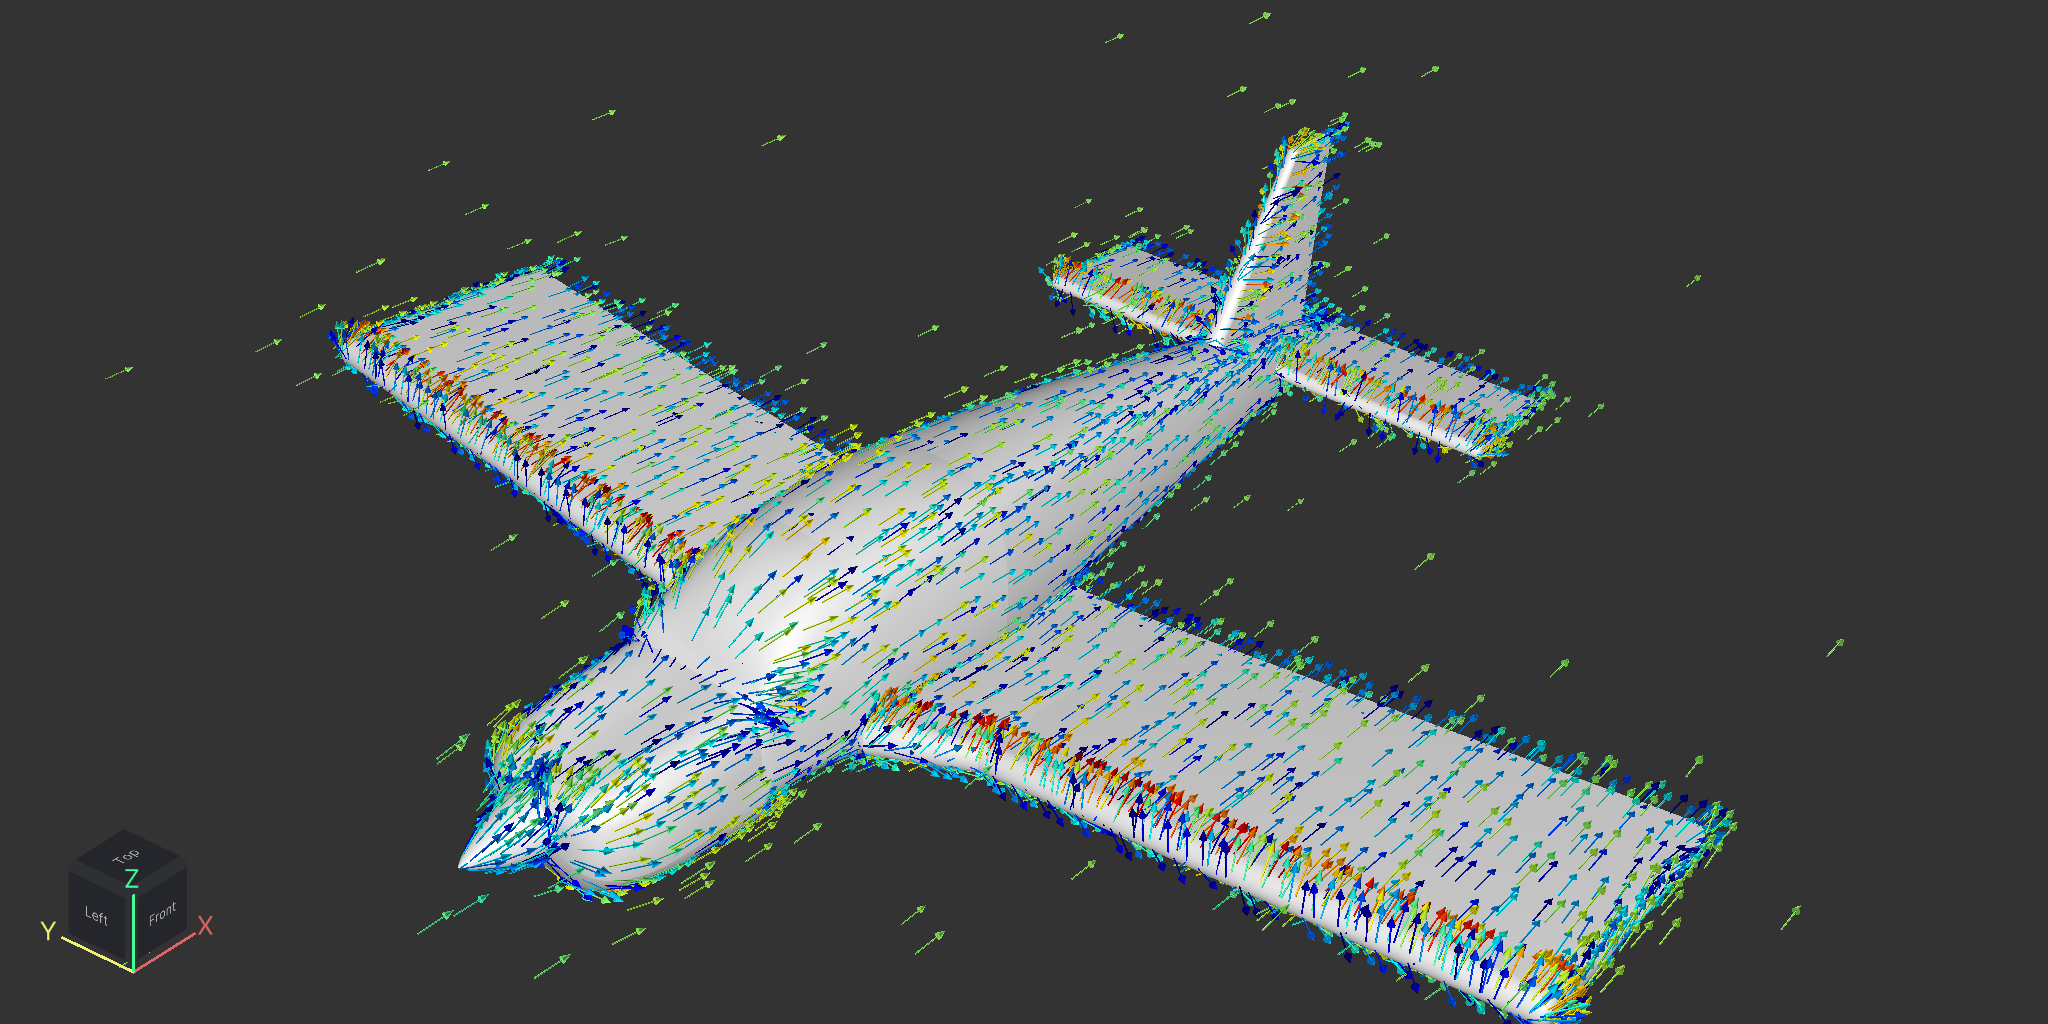

In [128]:
scene = vis.Scene(solution)
# Hide the far field surface
scene.hide_far_field()
scene.global_display_attrs.representation = vis.Representation.SURFACE
scene.global_display_attrs.field.quantity = vis.VisQuantity.NONE

camera = vis.LookAtCamera()
camera.look_at = [4.0, 0.0, 0.0]
camera.position = [-4.0, -7.0, 7.0]
camera.projection = vis.CameraProjection.PERSPECTIVE
camera.width = 2048
camera.height = 1024
scene.add_camera(camera)

# Add a slice to visualize the volume solution.
glyph = vis.FixedSizeVectorGlyphs("glyphs")
glyph.field.quantity = vis.VisQuantity.VELOCITY
glyph.sampling_rate = 1000
glyph.size = 0.2
glyph.display_attrs.representation = vis.Representation.SURFACE
glyph.display_attrs.field.quantity = vis.VisQuantity.VELOCITY
glyph.display_attrs.field.component = vis.FieldComponent.MAGNITUDE
scene.add_filter(glyph)

# Use a higher resolution to reduce line aliasing.
image_extract = scene.render_images(
    name="piper volume solution", description="Piper volume solution visualization."
)
status = image_extract.wait()
if status == vis.RenderStatusType.COMPLETED:
    image_buffer, label = image_extract.download_images()[0]
    image = Image.open(image_buffer)
    display(image)
else:
    print("Image extract failed ", status)